In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cpcb_raw.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (3402, 11)


In [4]:
df_clean = df.copy()

In [5]:
df_clean["last_update"] = pd.to_datetime(
    df_clean["last_update"],
    errors="coerce"
)

In [6]:
print(df_clean["last_update"].dtype)

datetime64[us]


In [7]:
print("Before:", len(df_clean))

df_clean = df_clean.drop_duplicates()

print("After:", len(df_clean))

Before: 3402
After: 2648


In [8]:
print(df_clean.isnull().sum())

country           0
state             0
city              0
station           0
last_update       0
latitude          0
longitude         0
pollutant_id      0
min_value       257
max_value       257
avg_value       257
dtype: int64


In [9]:
missing = df_clean[df_clean["avg_value"].isna()]

print("Rows with missing average:", len(missing))

Rows with missing average: 257


In [10]:
print(missing["pollutant_id"].value_counts())

pollutant_id
NH3      64
PM2.5    39
PM10     38
SO2      37
NO2      33
OZONE    28
CO       18
Name: count, dtype: int64


In [11]:
print("Earliest:", df_clean["last_update"].min())
print("Latest:", df_clean["last_update"].max())

Earliest: 2026-09-08 14:00:00
Latest: 2026-09-08 14:00:00


In [12]:
print(df_clean.shape)
print(df_clean.isnull().sum())
print(df_clean["pollutant_id"].value_counts())
print(df_clean["last_update"].min())
print(df_clean["last_update"].max())

(2648, 11)
country           0
state             0
city              0
station           0
last_update       0
latitude          0
longitude         0
pollutant_id      0
min_value       257
max_value       257
avg_value       257
dtype: int64
pollutant_id
PM2.5    387
CO       385
PM10     383
NO2      383
NH3      376
OZONE    372
SO2      362
Name: count, dtype: int64
2026-09-08 14:00:00
2026-09-08 14:00:00


In [13]:
# ==========================================
# STEP 5: Convert pollutant rows into columns
# ==========================================

df_ml = df_clean.copy()

print("Before pivot:", df_ml.shape)
print(df_ml.head())

Before pivot: (2648, 11)
  country         state     city                                    station  \
0   India  Chhattisgarh  Tumidih  OP Jindal Industrial Park, Tumidih - CECB   
1   India  Chhattisgarh  Tumidih  OP Jindal Industrial Park, Tumidih - CECB   
2   India         Delhi    Delhi                          ITO, Delhi - CPCB   
3   India         Delhi    Delhi                          ITO, Delhi - CPCB   
4   India         Delhi    Delhi                          ITO, Delhi - CPCB   

          last_update   latitude  longitude pollutant_id  min_value  \
0 2026-09-08 14:00:00  22.066315  83.338201          NH3        1.0   
1 2026-09-08 14:00:00  22.066315  83.338201        OZONE       14.0   
2 2026-09-08 14:00:00  28.628624  77.241060         PM10       23.0   
3 2026-09-08 14:00:00  28.628624  77.241060          NH3        3.0   
4 2026-09-08 14:00:00  28.628624  77.241060        OZONE       27.0   

   max_value  avg_value  
0        2.0        2.0  
1       23.0       18

In [14]:
df_ml = df_ml.pivot_table(
    index=[
        "country",
        "state",
        "city",
        "station",
        "latitude",
        "longitude",
        "last_update"
    ],
    columns="pollutant_id",
    values="avg_value",
    aggfunc="mean"
).reset_index()

print("After pivot:", df_ml.shape)
print(df_ml.head())
print(df_ml.columns)

After pivot: (483, 14)
pollutant_id country           state       city  \
0              India  Andhra Pradesh  Amaravati   
1              India  Andhra Pradesh  Anantapur   
2              India  Andhra Pradesh   Chittoor   
3              India  Andhra Pradesh      Eluru   
4              India  Andhra Pradesh     Guntur   

pollutant_id                               station   latitude  longitude  \
0                   Secretariat, Amaravati - APPCB  16.515083  80.518167   
1                     Gulzarpet, Anantapur - APPCB  14.675886  77.593027   
2              Gangineni Cheruvu, Chittoor - APPCB  13.204880  79.097889   
3                    District Court, Eluru - APPCB  16.711754  81.092095   
4             Rajendra Nagar North, Guntur - APPCB  16.316553  80.413302   

pollutant_id         last_update    CO  NH3   NO2  OZONE  PM10  PM2.5   SO2  
0            2026-09-08 14:00:00  11.0  4.0   NaN    NaN  76.0   28.0   NaN  
1            2026-09-08 14:00:00   NaN  3.0   NaN    NaN 

In [15]:
print(df_ml.shape)

print("\nMissing values:")
print(df_ml.isnull().sum())

print("\nColumns:")
print(df_ml.columns.tolist())

(483, 14)

Missing values:
pollutant_id
country          0
state            0
city             0
station          0
latitude         0
longitude        0
last_update      0
CO             116
NH3            171
NO2            133
OZONE          139
PM10           138
PM2.5          135
SO2            158
dtype: int64

Columns:
['country', 'state', 'city', 'station', 'latitude', 'longitude', 'last_update', 'CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']


In [16]:
# ==========================================
# STEP 6: Handle Missing Pollutant Values
# ==========================================

pollutants = [
    "CO",
    "NH3",
    "NO2",
    "OZONE",
    "PM10",
    "PM2.5",
    "SO2"
]

# Convert pollutant columns to numeric
for col in pollutants:
    df_ml[col] = pd.to_numeric(df_ml[col], errors="coerce")

# Fill missing values using median
for col in pollutants:
    median_value = df_ml[col].median()
    df_ml[col] = df_ml[col].fillna(median_value)

print("Missing values after imputation:")
print(df_ml[pollutants].isnull().sum())

Missing values after imputation:
pollutant_id
CO       0
NH3      0
NO2      0
OZONE    0
PM10     0
PM2.5    0
SO2      0
dtype: int64


In [17]:
print("\nDataset shape:", df_ml.shape)

print("\nData types:")
print(df_ml.dtypes)

print("\nPollutant statistics:")
print(df_ml[pollutants].describe())


Dataset shape: (483, 14)

Data types:
pollutant_id
country                   str
state                     str
city                      str
station                   str
latitude              float64
longitude             float64
last_update    datetime64[us]
CO                    float64
NH3                   float64
NO2                   float64
OZONE                 float64
PM10                  float64
PM2.5                 float64
SO2                   float64
dtype: object

Pollutant statistics:
pollutant_id          CO         NH3         NO2       OZONE        PM10  \
count         483.000000  483.000000  483.000000  483.000000  483.000000   
mean           27.318841    4.430642   17.668737   22.042443   55.989648   
std            15.378145    2.890974   12.480940   18.355745   22.899879   
min             1.000000    0.000000    0.000000    0.000000    3.000000   
25%            18.000000    3.000000   11.000000   15.000000   45.000000   
50%            25.000000    4.00000

In [18]:
# ==========================================
# STEP 7.1: Prepare data for AQI calculation
# ==========================================

df_aqi = df_clean.copy()

pollutants = [
    "CO",
    "NH3",
    "NO2",
    "OZONE",
    "PM10",
    "PM2.5",
    "SO2"
]

# Pivot pollutant rows into columns
df_aqi = df_aqi.pivot_table(
    index=[
        "country",
        "state",
        "city",
        "station",
        "latitude",
        "longitude",
        "last_update"
    ],
    columns="pollutant_id",
    values="avg_value",
    aggfunc="mean"
).reset_index()

# Remove the columns index name
df_aqi.columns.name = None

print("AQI dataset shape:", df_aqi.shape)
print(df_aqi.head())

AQI dataset shape: (483, 14)
  country           state       city                               station  \
0   India  Andhra Pradesh  Amaravati        Secretariat, Amaravati - APPCB   
1   India  Andhra Pradesh  Anantapur          Gulzarpet, Anantapur - APPCB   
2   India  Andhra Pradesh   Chittoor   Gangineni Cheruvu, Chittoor - APPCB   
3   India  Andhra Pradesh      Eluru         District Court, Eluru - APPCB   
4   India  Andhra Pradesh     Guntur  Rajendra Nagar North, Guntur - APPCB   

    latitude  longitude         last_update    CO  NH3   NO2  OZONE  PM10  \
0  16.515083  80.518167 2026-09-08 14:00:00  11.0  4.0   NaN    NaN  76.0   
1  14.675886  77.593027 2026-09-08 14:00:00   NaN  3.0   NaN    NaN   NaN   
2  13.204880  79.097889 2026-09-08 14:00:00  15.0  NaN   NaN    NaN   NaN   
3  16.711754  81.092095 2026-09-08 14:00:00   NaN  NaN  12.0   60.0  49.0   
4  16.316553  80.413302 2026-09-08 14:00:00  29.0  NaN   NaN   20.0  52.0   

   PM2.5   SO2  
0   28.0   NaN  
1   6

In [19]:
# ==========================================
# STEP 7.2: CPCB AQI Breakpoints
# ==========================================

AQI_BREAKPOINTS = {

    "PM2.5": {
        "concentration": [0, 30, 60, 90, 120, 250],
        "aqi":           [0, 50, 100, 200, 300, 400, 500]
    },

    "PM10": {
        "concentration": [0, 50, 100, 250, 350, 430],
        "aqi":           [0, 50, 100, 200, 300, 400, 500]
    },

    "NO2": {
        "concentration": [0, 40, 80, 180, 280, 400],
        "aqi":           [0, 50, 100, 200, 300, 400, 500]
    },

    "SO2": {
        "concentration": [0, 40, 80, 380, 800, 1600],
        "aqi":           [0, 50, 100, 200, 300, 400, 500]
    },

    "CO": {
        "concentration": [0, 1.0, 2.0, 10.0, 17.0, 34.0],
        "aqi":           [0, 50, 100, 200, 300, 400, 500]
    },

    "OZONE": {
        "concentration": [0, 50, 100, 168, 208, 748],
        "aqi":           [0, 50, 100, 200, 300, 400, 500]
    },

    "NH3": {
        "concentration": [0, 200, 400, 800, 1200, 1800],
        "aqi":           [0, 50, 100, 200, 300, 400, 500]
    }
}

In [20]:
# ==========================================
# STEP 7.3: Calculate pollutant sub-index
# ==========================================

def calculate_sub_index(concentration, pollutant):

    if pd.isna(concentration):
        return None

    bp = AQI_BREAKPOINTS[pollutant]

    concentrations = bp["concentration"]
    aqi_values = bp["aqi"]

    # Below minimum
    if concentration < concentrations[0]:
        return 0

    # Find appropriate breakpoint
    for i in range(len(concentrations) - 1):

        B_low = concentrations[i]
        B_high = concentrations[i + 1]

        I_low = aqi_values[i]
        I_high = aqi_values[i + 1]

        if B_low <= concentration <= B_high:

            sub_index = (
                ((I_high - I_low) / (B_high - B_low))
                * (concentration - B_low)
                + I_low
            )

            return round(sub_index, 2)

    # Above highest breakpoint
    if concentration > concentrations[-1]:

        B_low = concentrations[-1]
        B_high = concentrations[-1] * 2

        I_low = aqi_values[-1]
        I_high = 500

        sub_index = (
            ((I_high - I_low) / (B_high - B_low))
            * (concentration - B_low)
            + I_low
        )

        return min(round(sub_index, 2), 500)

    return None

In [21]:
print("PM2.5 = 30:",
      calculate_sub_index(30, "PM2.5"))

print("PM2.5 = 60:",
      calculate_sub_index(60, "PM2.5"))

print("PM10 = 50:",
      calculate_sub_index(50, "PM10"))

print("NO2 = 40:",
      calculate_sub_index(40, "NO2"))

PM2.5 = 30: 50.0
PM2.5 = 60: 100.0
PM10 = 50: 50.0
NO2 = 40: 50.0


In [22]:
# ==========================================
# STEP 7.5: Calculate pollutant sub-indices
# ==========================================

for pollutant in pollutants:

    df_aqi[pollutant + "_AQI"] = df_aqi[pollutant].apply(
        lambda x: calculate_sub_index(x, pollutant)
    )

print(df_aqi.head())

  country           state       city                               station  \
0   India  Andhra Pradesh  Amaravati        Secretariat, Amaravati - APPCB   
1   India  Andhra Pradesh  Anantapur          Gulzarpet, Anantapur - APPCB   
2   India  Andhra Pradesh   Chittoor   Gangineni Cheruvu, Chittoor - APPCB   
3   India  Andhra Pradesh      Eluru         District Court, Eluru - APPCB   
4   India  Andhra Pradesh     Guntur  Rajendra Nagar North, Guntur - APPCB   

    latitude  longitude         last_update    CO  NH3   NO2  ...  PM10  \
0  16.515083  80.518167 2026-09-08 14:00:00  11.0  4.0   NaN  ...  76.0   
1  14.675886  77.593027 2026-09-08 14:00:00   NaN  3.0   NaN  ...   NaN   
2  13.204880  79.097889 2026-09-08 14:00:00  15.0  NaN   NaN  ...   NaN   
3  16.711754  81.092095 2026-09-08 14:00:00   NaN  NaN  12.0  ...  49.0   
4  16.316553  80.413302 2026-09-08 14:00:00  29.0  NaN   NaN  ...  52.0   

   PM2.5   SO2  CO_AQI  NH3_AQI  NO2_AQI  OZONE_AQI  PM10_AQI  PM2.5_AQI  \
0   

In [23]:
# ==========================================
# STEP 7.6: Calculate Overall AQI
# ==========================================

sub_index_columns = [
    "PM2.5_AQI",
    "PM10_AQI",
    "NO2_AQI",
    "SO2_AQI",
    "CO_AQI",
    "OZONE_AQI",
    "NH3_AQI"
]

df_aqi["AQI"] = df_aqi[sub_index_columns].max(axis=1)

print(df_aqi[[
    "station",
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "OZONE",
    "NH3",
    "AQI"
]].head(10))

                                          station  PM2.5  PM10   NO2   SO2  \
0                  Secretariat, Amaravati - APPCB   28.0  76.0   NaN   NaN   
1                    Gulzarpet, Anantapur - APPCB   63.0   NaN   NaN   NaN   
2             Gangineni Cheruvu, Chittoor - APPCB    NaN   NaN   NaN   NaN   
3                   District Court, Eluru - APPCB    NaN  49.0  12.0  14.0   
4            Rajendra Nagar North, Guntur - APPCB    NaN  52.0   NaN  10.0   
5                 Yerramukkapalli, Kadapa - APPCB   71.0  66.0  25.0   NaN   
6                Ambedkar Nagar, Nellore - APPCB     NaN  55.0  32.0  10.0   
7  Anand Kala Kshetram, Rajamahendravaram - APPCB   31.0  55.0   7.0   NaN   
8                     Toll Gate, Tirumala - APPCB   15.0  25.0  41.0   6.0   
9                 Vaikuntapuram, Tirupati - APPCB    NaN  55.0  30.0  12.0   

     CO  OZONE  NH3     AQI  
0  11.0    NaN  4.0  214.29  
1   NaN    NaN  3.0  110.00  
2  15.0    NaN  NaN  271.43  
3   NaN   60.0  NaN  

In [24]:
# ==========================================
# STEP 7.7: Create AQI Category
# ==========================================

def get_aqi_category(aqi):

    if pd.isna(aqi):
        return None

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Satisfactory"

    elif aqi <= 200:
        return "Moderate"

    elif aqi <= 300:
        return "Poor"

    elif aqi <= 400:
        return "Very Poor"

    else:
        return "Severe"


df_aqi["AQI_Category"] = df_aqi["AQI"].apply(get_aqi_category)

print(df_aqi[["station", "AQI", "AQI_Category"]].head(20))

                                           station     AQI  AQI_Category
0                   Secretariat, Amaravati - APPCB  214.29          Poor
1                     Gulzarpet, Anantapur - APPCB  110.00      Moderate
2              Gangineni Cheruvu, Chittoor - APPCB  271.43          Poor
3                    District Court, Eluru - APPCB   60.00  Satisfactory
4             Rajendra Nagar North, Guntur - APPCB  370.59     Very Poor
5                  Yerramukkapalli, Kadapa - APPCB  136.67      Moderate
6                 Ambedkar Nagar, Nellore - APPCB   500.00        Severe
7   Anand Kala Kshetram, Rajamahendravaram - APPCB  300.00          Poor
8                      Toll Gate, Tirumala - APPCB  341.18     Very Poor
9                  Vaikuntapuram, Tirupati - APPCB  329.41     Very Poor
10                   HB Colony, Vijayawada - APPCB  388.24     Very Poor
11                 Rajiv Nagar, Vijayawada - APPCB  358.82     Very Poor
12          GVM Corporation, Visakhapatnam - APPCB 

In [25]:
print("\nAQI statistics:")
print(df_aqi["AQI"].describe())

print("\nAQI Category distribution:")
print(df_aqi["AQI_Category"].value_counts())

print("\nMissing AQI:")
print(df_aqi["AQI"].isnull().sum())


AQI statistics:
count    483.000000
mean     283.465839
std      159.837667
min        0.250000
25%      148.335000
50%      311.760000
75%      391.180000
max      500.000000
Name: AQI, dtype: float64

AQI Category distribution:
AQI_Category
Very Poor       147
Severe          104
Poor             79
Satisfactory     60
Good             48
Moderate         45
Name: count, dtype: int64

Missing AQI:
0


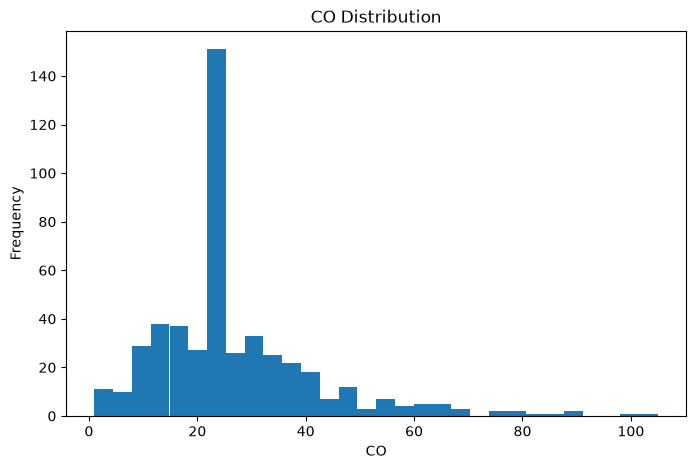

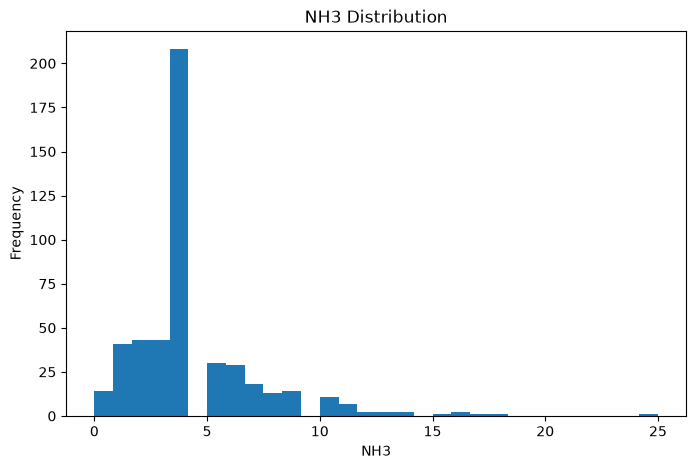

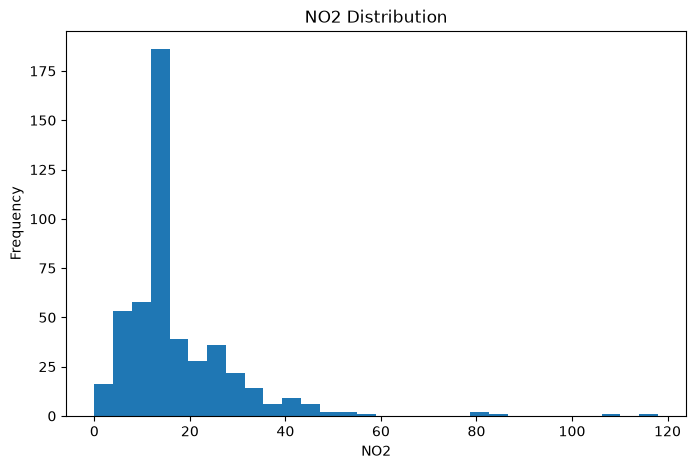

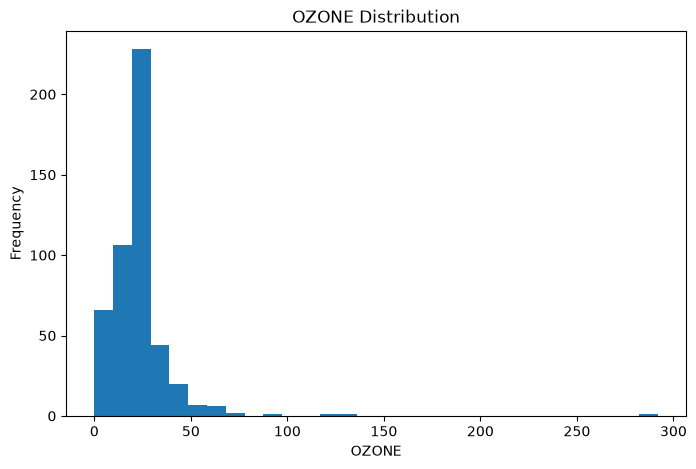

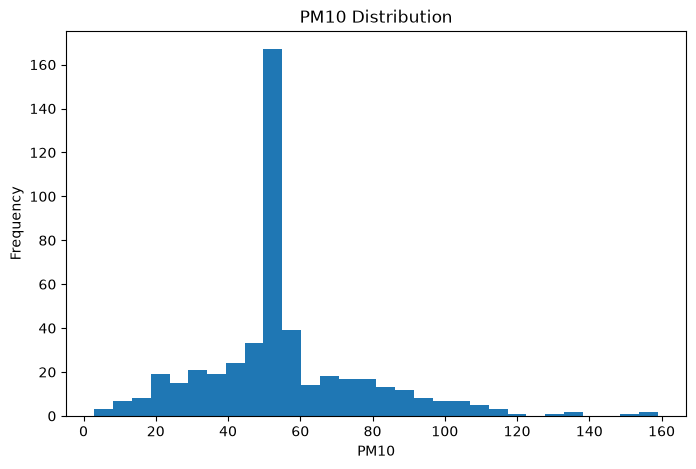

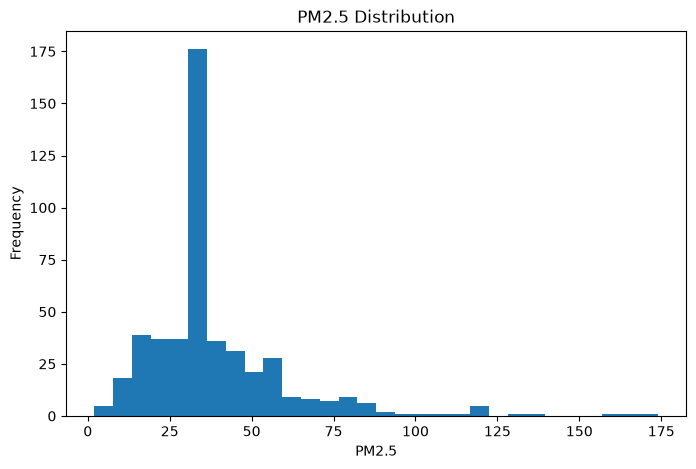

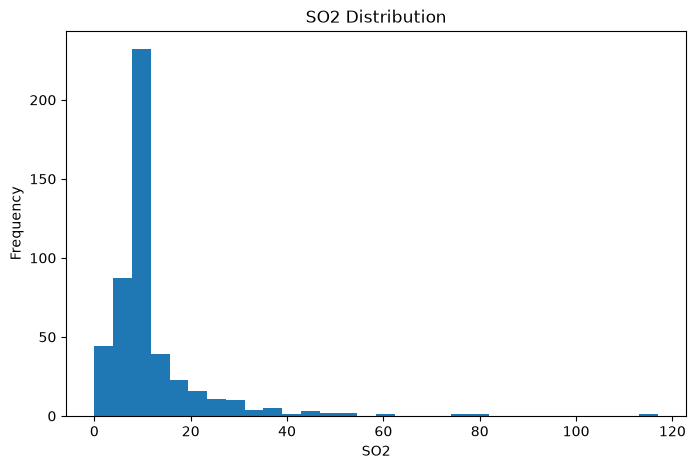

In [26]:
import matplotlib.pyplot as plt

# Pollutant columns
pollutants = ['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']

# Plot pollutant distributions
for pollutant in pollutants:
    plt.figure(figsize=(8, 5))
    plt.hist(df_ml[pollutant].dropna(), bins=30)
    plt.xlabel(pollutant)
    plt.ylabel("Frequency")
    plt.title(f"{pollutant} Distribution")
    plt.show()

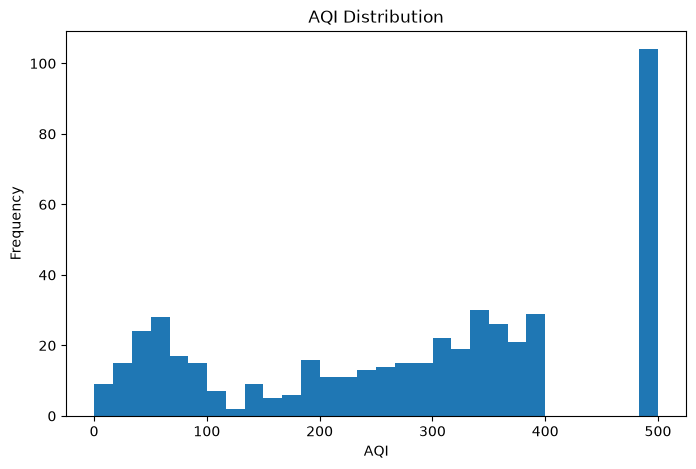

In [27]:
# AQI distribution

plt.figure(figsize=(8, 5))
plt.hist(df_aqi["AQI"], bins=30)
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("AQI Distribution")
plt.show()

In [28]:
# Correlation between pollutants and AQI

correlation = df_ml[pollutants].corrwith(df_aqi["AQI"])

print("Correlation with AQI:")
print(correlation.sort_values(ascending=False))

Correlation with AQI:
pollutant_id
CO       0.603943
PM2.5    0.193599
NO2      0.135041
PM10     0.120677
NH3      0.102436
OZONE    0.080965
SO2      0.037756
dtype: float64


In [29]:
# Copy the ML dataset
df_model = df_ml.copy()

# Add AQI and AQI category
df_model["AQI"] = df_aqi["AQI"].values
df_model["AQI_Category"] = df_aqi["AQI_Category"].values

print("Dataset shape:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

Dataset shape: (483, 16)

Columns:
['country', 'state', 'city', 'station', 'latitude', 'longitude', 'last_update', 'CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2', 'AQI', 'AQI_Category']


In [30]:
print(df_model.isnull().sum())

pollutant_id
country         0
state           0
city            0
station         0
latitude        0
longitude       0
last_update     0
CO              0
NH3             0
NO2             0
OZONE           0
PM10            0
PM2.5           0
SO2             0
AQI             0
AQI_Category    0
dtype: int64


In [31]:
features = [
    "CO",
    "NH3",
    "NO2",
    "OZONE",
    "PM10",
    "PM2.5",
    "SO2"
]

target = "AQI_Category"

X = df_model[features]
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (483, 7)
y shape: (483,)


In [32]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

X = pd.DataFrame(
    X_imputed,
    columns=features,
    index=X.index
)

print("Missing values after imputation:")
print(X.isnull().sum())

Missing values after imputation:
CO       0
NH3      0
NO2      0
OZONE    0
PM10     0
PM2.5    0
SO2      0
dtype: int64


In [33]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

Classes:
['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']


In [34]:
for i, category in enumerate(label_encoder.classes_):
    print(i, "->", category)

0 -> Good
1 -> Moderate
2 -> Poor
3 -> Satisfactory
4 -> Severe
5 -> Very Poor


In [35]:
print("Class distribution:")
print(y.value_counts())

Class distribution:
AQI_Category
Very Poor       147
Severe          104
Poor             79
Satisfactory     60
Good             48
Moderate         45
Name: count, dtype: int64


In [36]:
class_weight="balanced"

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (386, 7)
Testing data: (97, 7)


In [38]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClasses:")
print(label_encoder.classes_)

print("\nTraining:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

X shape: (483, 7)
y shape: (483,)

Classes:
['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']

Training: (386, 7)
Testing: (97, 7)

Training class distribution:
5    118
4     83
2     63
3     48
0     38
1     36
Name: count, dtype: int64


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Feature scaling completed!
X_train_scaled shape: (386, 7)
X_test_scaled shape: (97, 7)


In [41]:
logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [42]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM trained successfully!")

SVM trained successfully!


In [43]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Decision Tree and Random Forest trained successfully!")

Decision Tree and Random Forest trained successfully!


In [44]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

y_pred_svm = svm_model.predict(X_test_scaled)

y_pred_dt = dt_model.predict(X_test)

y_pred_rf = rf_model.predict(X_test)

print("All predictions completed!")

All predictions completed!


In [45]:
from sklearn.metrics import accuracy_score

accuracy_results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_logistic),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

print("\nModel Accuracy:")
print("-" * 40)

for model, accuracy in accuracy_results.items():
    print(f"{model}: {accuracy:.4f}")


Model Accuracy:
----------------------------------------
Logistic Regression: 0.6392
Decision Tree: 0.8660
Random Forest: 0.8660
SVM: 0.5979


In [46]:
print("Random Forest Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

        Good       0.64      0.90      0.75        10
    Moderate       0.83      0.56      0.67         9
        Poor       1.00      0.94      0.97        16
Satisfactory       0.86      0.50      0.63        12
      Severe       1.00      1.00      1.00        21
   Very Poor       0.82      0.97      0.89        29

    accuracy                           0.87        97
   macro avg       0.86      0.81      0.82        97
weighted avg       0.88      0.87      0.86        97



<Figure size 800x600 with 0 Axes>

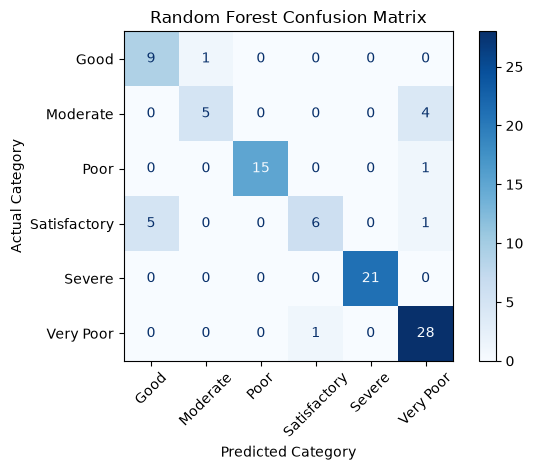

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=label_encoder.classes_,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
models = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

for name, predictions in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=label_encoder.classes_
        )
    )


Logistic Regression
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        10
    Moderate       0.50      0.11      0.18         9
        Poor       0.76      1.00      0.86        16
Satisfactory       0.00      0.00      0.00        12
      Severe       1.00      1.00      1.00        21
   Very Poor       0.50      0.83      0.62        29

    accuracy                           0.64        97
   macro avg       0.46      0.49      0.45        97
weighted avg       0.54      0.64      0.56        97


Decision Tree
              precision    recall  f1-score   support

        Good       0.67      0.60      0.63        10
    Moderate       1.00      0.56      0.71         9
        Poor       1.00      1.00      1.00        16
Satisfactory       0.50      0.67      0.57        12
      Severe       1.00      1.00      1.00        21
   Very Poor       0.93      0.97      0.95        29

    accuracy                           0.

/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<Figure size 800x600 with 0 Axes>

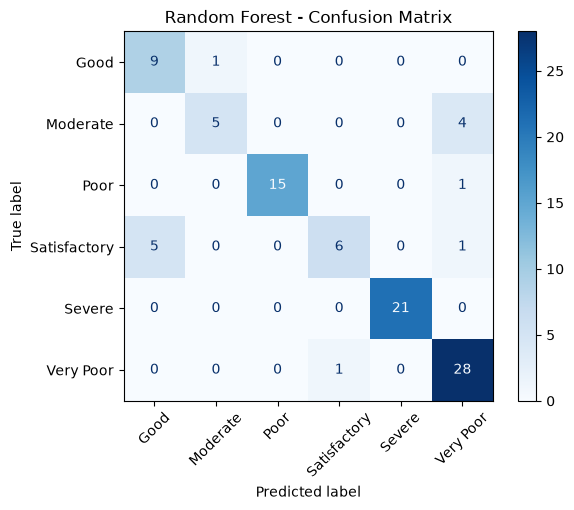

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Random Forest confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Random Forest - Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

In [50]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

  Feature  Importance
0      CO    0.540115
5   PM2.5    0.099238
4    PM10    0.084614
3   OZONE    0.081496
2     NO2    0.073752
6     SO2    0.066383
1     NH3    0.054403


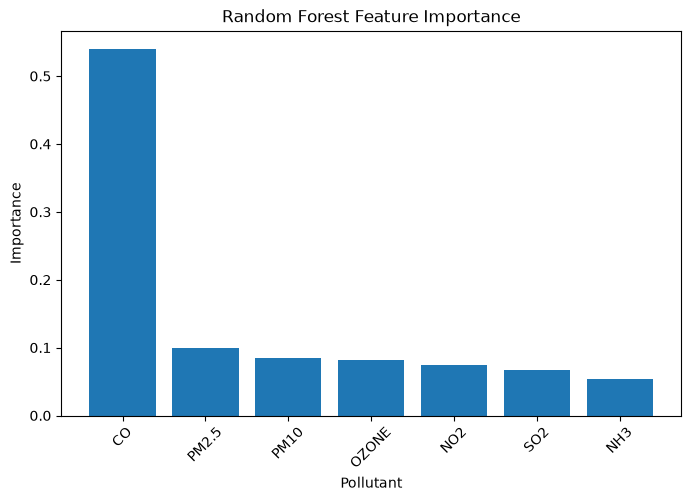

In [51]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Pollutant")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

In [53]:
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        10
    Moderate       0.50      0.11      0.18         9
        Poor       0.76      1.00      0.86        16
Satisfactory       0.00      0.00      0.00        12
      Severe       1.00      1.00      1.00        21
   Very Poor       0.50      0.83      0.62        29

    accuracy                           0.64        97
   macro avg       0.46      0.49      0.45        97
weighted avg       0.54      0.64      0.56        97



In [54]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best CV Score:
0.8618511581073672


In [56]:
best_rf = grid_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

In [57]:
print(classification_report(
    y_test,
    y_pred_best_rf,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

        Good       0.60      0.90      0.72        10
    Moderate       0.83      0.56      0.67         9
        Poor       0.84      1.00      0.91        16
Satisfactory       0.60      0.50      0.55        12
      Severe       1.00      1.00      1.00        21
   Very Poor       0.85      0.76      0.80        29

    accuracy                           0.81        97
   macro avg       0.79      0.79      0.77        97
weighted avg       0.82      0.81      0.81        97



In [58]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross Validation Scores:
[0.88659794 0.83505155 0.8556701  0.90625    0.88541667]

Mean CV Accuracy:
0.8737972508591065

Standard Deviation:
0.025226464065732476


In [59]:
from sklearn.metrics import accuracy_score, f1_score

results = {
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_logistic, average="macro")
    ],

    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt, average="macro")
    ],

    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf, average="macro")
    ],

    "SVM": [
        accuracy_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm, average="macro")
    ]
}

results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Macro F1"]
).T

print(results_df)

                     Accuracy  Macro F1
Logistic Regression  0.639175  0.445010
Decision Tree        0.865979  0.811074
Random Forest        0.865979  0.817479
SVM                  0.597938  0.384251


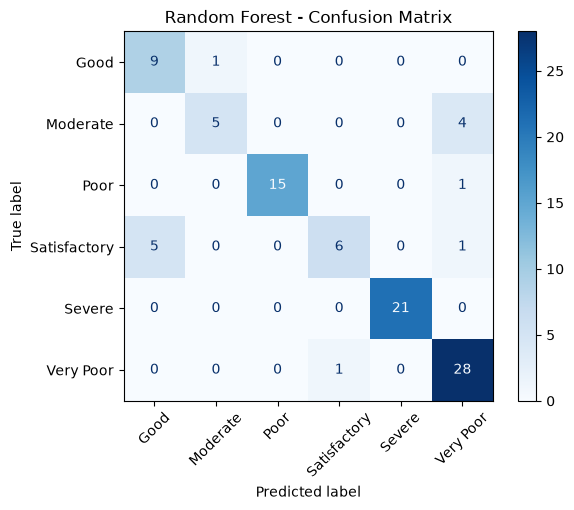

In [60]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest - Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

In [61]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

  Feature  Importance
0      CO    0.540115
5   PM2.5    0.099238
4    PM10    0.084614
3   OZONE    0.081496
2     NO2    0.073752
6     SO2    0.066383
1     NH3    0.054403


In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best CV Score:
0.8618511581073672


In [63]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross Validation Scores:
[0.88659794 0.83505155 0.8556701  0.90625    0.88541667]

Mean CV Accuracy:
0.8737972508591065

Standard Deviation:
0.025226464065732476


In [64]:
cv_f1 = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

print("Cross Validation F1 Scores:")
print(cv_f1)

print("\nMean CV Macro F1:")
print(cv_f1.mean())

print("\nStandard Deviation:")
print(cv_f1.std())

Cross Validation F1 Scores:
[0.85821736 0.80288081 0.83146436 0.89550555 0.86255069]

Mean CV Macro F1:
0.8501237536537453

Standard Deviation:
0.031175345820278488


In [65]:
y_pred_best_rf = best_rf.predict(X_test)

print(classification_report(
    y_test,
    y_pred_best_rf,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

        Good       0.60      0.90      0.72        10
    Moderate       0.83      0.56      0.67         9
        Poor       0.84      1.00      0.91        16
Satisfactory       0.60      0.50      0.55        12
      Severe       1.00      1.00      1.00        21
   Very Poor       0.85      0.76      0.80        29

    accuracy                           0.81        97
   macro avg       0.79      0.79      0.77        97
weighted avg       0.82      0.81      0.81        97



In [66]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:",
      accuracy_score(y_test, y_pred_best_rf))

print("Macro F1:",
      f1_score(y_test, y_pred_best_rf, average="macro"))

print("Weighted F1:",
      f1_score(y_test, y_pred_best_rf, average="weighted"))

Accuracy: 0.8144329896907216
Macro F1: 0.7744011544011543
Weighted F1: 0.8100415048868657


In [67]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross-Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-Validation Scores:
[0.82474227 0.90721649 0.87628866 0.84375    0.94791667]

Mean CV Accuracy: 0.8799828178694158
Standard Deviation: 0.044124059681772576


In [68]:
from sklearn.metrics import classification_report, accuracy_score

# Train best model on training data
best_rf.fit(X_train, y_train)

# Predictions
y_pred_best_rf = best_rf.predict(X_test)

print("=" * 60)
print("FINAL RANDOM FOREST MODEL")
print("=" * 60)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred_best_rf))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_best_rf,
        target_names=label_encoder.classes_
    )
)

FINAL RANDOM FOREST MODEL

Accuracy:
0.8144329896907216

Classification Report:
              precision    recall  f1-score   support

        Good       0.60      0.90      0.72        10
    Moderate       0.83      0.56      0.67         9
        Poor       0.84      1.00      0.91        16
Satisfactory       0.60      0.50      0.55        12
      Severe       1.00      1.00      1.00        21
   Very Poor       0.85      0.76      0.80        29

    accuracy                           0.81        97
   macro avg       0.79      0.79      0.77        97
weighted avg       0.82      0.81      0.81        97



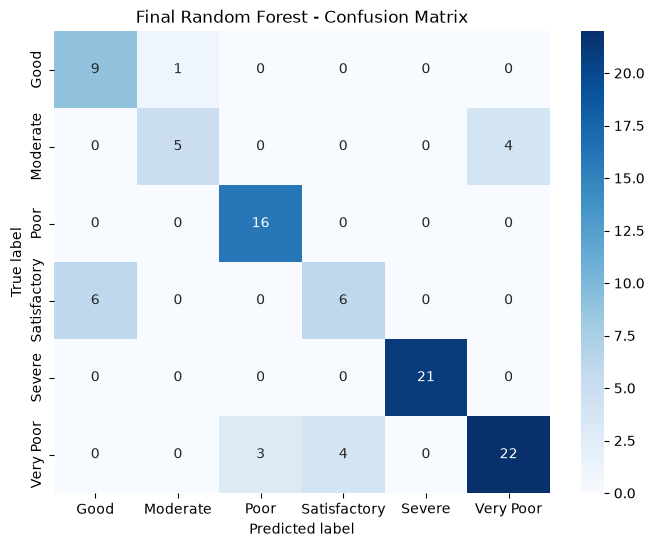

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Final Random Forest - Confusion Matrix")

plt.show()

In [70]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

  Feature  Importance
0      CO    0.501506
5   PM2.5    0.116715
4    PM10    0.099157
2     NO2    0.078881
3   OZONE    0.078165
6     SO2    0.066448
1     NH3    0.059128


In [71]:
import joblib

# Save final Random Forest model
joblib.dump(best_rf, "random_forest_aqi_model.pkl")

# Save label encoder
joblib.dump(label_encoder, "aqi_label_encoder.pkl")

# Save feature names
joblib.dump(pollutants, "aqi_features.pkl")

print("Model saved successfully!")

Model saved successfully!


In [72]:
# New AQI input
new_data = pd.DataFrame([{
    "CO": 30,
    "NH3": 5,
    "NO2": 20,
    "OZONE": 25,
    "PM10": 60,
    "PM2.5": 35,
    "SO2": 10
}])

# Make prediction
prediction = best_rf.predict(new_data)

# Convert encoded prediction back to category
predicted_category = label_encoder.inverse_transform(prediction)

print("Predicted AQI Category:", predicted_category[0])

Predicted AQI Category: Very Poor


In [73]:
def predict_aqi(CO, NH3, NO2, OZONE, PM10, PM2_5, SO2):

    input_data = pd.DataFrame([{
        "CO": CO,
        "NH3": NH3,
        "NO2": NO2,
        "OZONE": OZONE,
        "PM10": PM10,
        "PM2.5": PM2_5,
        "SO2": SO2
    }])

    prediction = best_rf.predict(input_data)

    category = label_encoder.inverse_transform(prediction)[0]

    return category

In [74]:
result = predict_aqi(
    CO=30,
    NH3=5,
    NO2=20,
    OZONE=25,
    PM10=60,
    PM2_5=35,
    SO2=10
)

print("Predicted AQI Category:", result)

Predicted AQI Category: Very Poor


In [75]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features
X_reg = df_ml[pollutants]

# Target
y_reg = df_aqi["AQI"]

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

X shape: (483, 7)
y shape: (483,)


In [76]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train_reg.shape)
print("Testing:", X_test_reg.shape)

Training: (386, 7)
Testing: (97, 7)


In [77]:
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_reg.fit(X_train_reg, y_train_reg)

print("AQI Regression Model trained successfully!")

AQI Regression Model trained successfully!


In [78]:
y_pred_reg = rf_reg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("AQI Regression Results")
print("=" * 50)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

AQI Regression Results
MAE : 13.965608263786512
RMSE: 39.82475140600492
R²  : 0.939232678138464


In [79]:
comparison = pd.DataFrame({
    "Actual AQI": y_test_reg.values,
    "Predicted AQI": np.round(y_pred_reg, 2)
})

print(comparison.head(15))

    Actual AQI  Predicted AQI
0       170.00         147.51
1       500.00         500.00
2       228.57         228.62
3       500.00         500.00
4       187.50         187.21
5       500.00         500.00
6        53.33          45.38
7         3.75          10.30
8       341.18         341.16
9       352.94         344.46
10      329.41         328.02
11      146.67         132.07
12      242.86         242.86
13      500.00         500.00
14      285.71         285.52


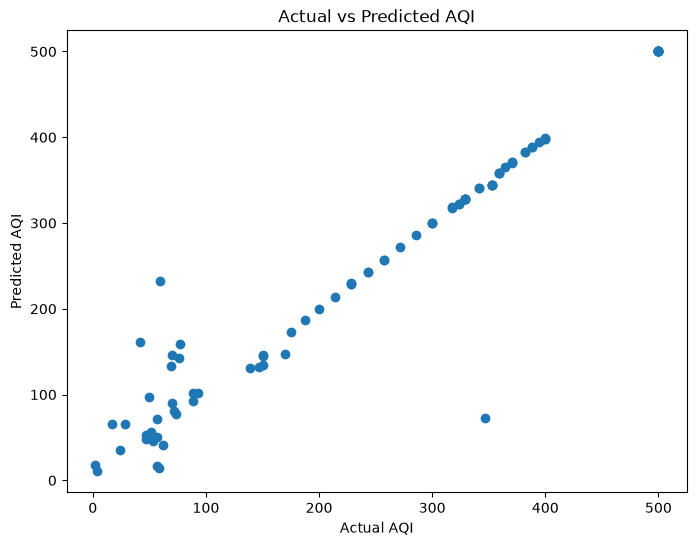

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test_reg, y_pred_reg)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()

In [81]:
def predict_aqi(co, nh3, no2, ozone, pm10, pm25, so2):

    input_data = [[
        co,
        nh3,
        no2,
        ozone,
        pm10,
        pm25,
        so2
    ]]

    # Predict AQI value
    predicted_aqi = best_aq_model.predict(input_data)[0]

    # Keep AQI within valid range if your dataset uses 0–500
    predicted_aqi = max(0, min(500, predicted_aqi))

    # Predict AQI category
    predicted_class = best_rf.predict(input_data)[0]

    category = label_encoder.inverse_transform(
        [predicted_class]
    )[0]

    return predicted_aqi, category

In [82]:
joblib.dump(rf_reg, "random_forest_aqi_regressor.pkl")

print("AQI regression model saved successfully!")

AQI regression model saved successfully!


In [83]:
def predict_aqi(
    CO,
    NH3,
    NO2,
    OZONE,
    PM10,
    PM2_5,
    SO2
):

    input_data = pd.DataFrame([{
        "CO": CO,
        "NH3": NH3,
        "NO2": NO2,
        "OZONE": OZONE,
        "PM10": PM10,
        "PM2.5": PM2_5,
        "SO2": SO2
    }])

    # Numerical AQI
    aqi_value = rf_reg.predict(input_data)[0]

    # AQI category
    category_prediction = best_rf.predict(input_data)

    category = label_encoder.inverse_transform(
        category_prediction
    )[0]

    return round(aqi_value, 2), category

In [84]:
aqi, category = predict_aqi(
    CO=30,
    NH3=5,
    NO2=20,
    OZONE=25,
    PM10=60,
    PM2_5=35,
    SO2=10
)

print("Predicted AQI :", aqi)
print("AQI Category  :", category)

Predicted AQI : 376.55
AQI Category  : Very Poor


In [85]:
test_input = {
    "CO": 1.2,
    "NH3": 20,
    "NO2": 45,
    "OZONE": 80,
    "PM10": 120,
    "PM2.5": 75,
    "SO2": 15
}

In [86]:
aqi, category = predict_aqi(
    test_input["CO"],
    test_input["NH3"],
    test_input["NO2"],
    test_input["OZONE"],
    test_input["PM10"],
    test_input["PM2.5"],
    test_input["SO2"]
)

print("Predicted AQI:", round(aqi, 2))
print("AQI Category:", category)

Predicted AQI: 124.84
AQI Category: Moderate


In [87]:
print(label_encoder.classes_)

['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']


In [88]:
print("Features:")
print(features)

print("\nClasses:")
print(label_encoder.classes_)

print("\nRegression model:")
print(rf_reg)

print("\nClassification model:")
print(best_rf)

Features:
['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']

Classes:
['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']

Regression model:
RandomForestRegressor(max_depth=20, n_estimators=300, random_state=42)

Classification model:
RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=300,
                       random_state=42)


In [89]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
AQI_BREAKPOINTS          dict                      n=7
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GridSearchCV             ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LabelEncoder             type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
NamespaceMagics          MetaHasTraits             <class 'IPython.core.magi<...>mespace.NamespaceMagics'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
RandomForestRegressor    ABCMeta                   <class 'sklearn.ensembl

In [90]:
import joblib

# Save Random Forest classification model
joblib.dump(best_rf, "random_forest_classifier.pkl")

# Save Random Forest regression model
joblib.dump(rf_reg, "aqi_regression_model.pkl")

# Save label encoder
joblib.dump(label_encoder, "aqi_label_encoder.pkl")

# Save feature names
joblib.dump(features, "aqi_features.pkl")

print("All models and preprocessing files saved successfully!")

All models and preprocessing files saved successfully!


In [91]:
import os

files_to_check = [
    "random_forest_classifier.pkl",
    "aqi_regression_model.pkl",
    "aqi_label_encoder.pkl",
    "aqi_features.pkl"
]

for file in files_to_check:
    print(file, "→", "FOUND" if os.path.exists(file) else "NOT FOUND")

random_forest_classifier.pkl → FOUND
aqi_regression_model.pkl → FOUND
aqi_label_encoder.pkl → FOUND
aqi_features.pkl → FOUND


In [92]:
import joblib

loaded_classifier = joblib.load("random_forest_classifier.pkl")
loaded_regressor = joblib.load("aqi_regression_model.pkl")
loaded_encoder = joblib.load("aqi_label_encoder.pkl")
loaded_features = joblib.load("aqi_features.pkl")

print("Classifier:", loaded_classifier)
print("Regressor:", loaded_regressor)
print("Classes:", loaded_encoder.classes_)
print("Features:", loaded_features)

Classifier: RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=300,
                       random_state=42)
Regressor: RandomForestRegressor(max_depth=20, n_estimators=300, random_state=42)
Classes: ['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']
Features: ['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']


In [93]:
sample_input = pd.DataFrame([{
    "CO": 1.2,
    "NH3": 10,
    "NO2": 40,
    "OZONE": 80,
    "PM10": 120,
    "PM2.5": 70,
    "SO2": 20
}])

# Make sure feature order is correct
sample_input = sample_input[loaded_features]

# AQI prediction
predicted_aqi = loaded_regressor.predict(sample_input)[0]

# Classification prediction
predicted_class = loaded_classifier.predict(sample_input)[0]

predicted_category = loaded_encoder.inverse_transform(
    [predicted_class]
)[0]

print("Predicted AQI:", round(predicted_aqi, 2))
print("Predicted Category:", predicted_category)

Predicted AQI: 123.17
Predicted Category: Moderate


In [94]:
import os

print(os.getcwd())
print(os.listdir())

/Users/aryanjain/Desktop/AQI/notebooks
['aqi_label_encoder.pkl', '.DS_Store', 'aqi_regression_model.pkl', 'random_forest_classifier.pkl', 'data_collection.ipynb', 'random_forest_aqi_regressor.pkl', 'data_preprocessing.ipynb', 'random_forest_aqi_model.pkl', '.ipynb_checkpoints', 'aqi_features.pkl']


In [95]:
import os

for root, dirs, files in os.walk("/Users/aryanjain/Desktop/AQI"):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

/Users/aryanjain/Desktop/AQI/models/aqi_label_encoder.pkl
/Users/aryanjain/Desktop/AQI/models/aqi_regression_model.pkl
/Users/aryanjain/Desktop/AQI/models/random_forest_classifier.pkl
/Users/aryanjain/Desktop/AQI/models/random_forest_aqi_regressor.pkl
/Users/aryanjain/Desktop/AQI/models/random_forest_aqi_model.pkl
/Users/aryanjain/Desktop/AQI/models/aqi_features.pkl
/Users/aryanjain/Desktop/AQI/notebooks/aqi_label_encoder.pkl
/Users/aryanjain/Desktop/AQI/notebooks/aqi_regression_model.pkl
/Users/aryanjain/Desktop/AQI/notebooks/random_forest_classifier.pkl
/Users/aryanjain/Desktop/AQI/notebooks/random_forest_aqi_regressor.pkl
/Users/aryanjain/Desktop/AQI/notebooks/random_forest_aqi_model.pkl
/Users/aryanjain/Desktop/AQI/notebooks/aqi_features.pkl


In [96]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_rf, "../models/random_forest_classifier.joblib")
joblib.dump(rf_reg, "../models/aqi_regression_model.joblib")
joblib.dump(label_encoder, "../models/aqi_label_encoder.joblib")
joblib.dump(features, "../models/aqi_features.joblib")

print("Models saved successfully with joblib!")

Models saved successfully with joblib!


In [97]:
print("best_rf:", type(best_rf))
print("rf_reg:", type(rf_reg))
print("label_encoder:", type(label_encoder))
print("features:", features)

best_rf: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
rf_reg: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
label_encoder: <class 'sklearn.preprocessing._label.LabelEncoder'>
features: ['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']


In [98]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_rf,
    "../models/random_forest_classifier.joblib"
)

joblib.dump(
    rf_reg,
    "../models/aqi_regression_model.joblib"
)

joblib.dump(
    label_encoder,
    "../models/aqi_label_encoder.joblib"
)

joblib.dump(
    features,
    "../models/aqi_features.joblib"
)

print("Models saved successfully with joblib!")

Models saved successfully with joblib!


In [99]:
import os

for file in [
    "../models/random_forest_classifier.joblib",
    "../models/aqi_regression_model.joblib",
    "../models/aqi_label_encoder.joblib",
    "../models/aqi_features.joblib"
]:
    print(os.path.abspath(file), "->", os.path.exists(file))

/Users/aryanjain/Desktop/AQI/models/random_forest_classifier.joblib -> True
/Users/aryanjain/Desktop/AQI/models/aqi_regression_model.joblib -> True
/Users/aryanjain/Desktop/AQI/models/aqi_label_encoder.joblib -> True
/Users/aryanjain/Desktop/AQI/models/aqi_features.joblib -> True
